In [1]:
# --- Imports ---
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import set_random_seed

c:\Users\kelvy\anaconda3\envs\stat5810\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# For reproducibility
set_random_seed(42)

# --- Load dataset ---
data = load_breast_cancer()
X, y = data.data, data.target

# --- Standardize predictors ---
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [3]:
# --- Define MLP model builder ---
def build_mlp(input_dim):
    model = Sequential([
        Dense(32, activation="relu", input_shape=(input_dim,)),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

In [44]:
def clique(X, y, model_builder="rf", folds=5, nsim=25, quantile_grid=True, keras_model=False, 
            epochs=10, batch_size=32, random_state=123):
    """
    Python translation of the R clique function.
    
    Parameters
    ----------
    X : pd.DataFrame
        Predictor matrix
    y : pd.Series or np.array
        Response vector (numeric for regression, categorical for classification)
    model_type : str
        "rf" for random forest, "lm" for linear regression
    param_grid : dict
        Parameters for the chosen model (like tuneGrid in caret)
    nsim : int
        Number of grid points
    folds : int
        Number of CV folds
    quantile_grid : bool
        Whether to use quantiles (True) or uniform grid (False)
    random_state : int
        Reproducibility
    
    Returns
    -------
    dict with:
        - "models": list of fitted models (per fold)
        - "local_imp": pd.DataFrame of local importance values
    """
        
    X = pd.DataFrame(X)
    y = pd.Series(y)

    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=random_state)
    models = []
    
    # Train fold-specific models
    for train_idx, test_idx in skf.split(X, y):
        if model_builder == "rf":
            model = RandomForestClassifier(n_estimators=100, random_state=random_state)
        elif keras_model:
            model = model_builder(X.shape[1])  # build keras model
        else:
            model = model_builder  # assume it's already an sklearn estimator

        if keras_model:
            model.fit(X.iloc[train_idx], y.iloc[train_idx],
                      epochs=epochs, batch_size=batch_size, verbose=0,
                      validation_data=(X.iloc[test_idx], y.iloc[test_idx]))
        else:
            model.fit(X.iloc[train_idx], y.iloc[train_idx])

        models.append(model)

    # Collect predictions (truth vs. preds)
    truth = y.values
    preds = np.zeros_like(truth, dtype=float)

    for fold, (_, test_idx) in enumerate(skf.split(X, y)):
        if keras_model:
            preds[test_idx] = models[fold].predict(X.iloc[test_idx]).ravel()
        else:
            preds[test_idx] = models[fold].predict_proba(X.iloc[test_idx])[:, 1]

    base_mse = (truth - preds) ** 2

    # Importance calculation
    local_imp = pd.DataFrame(0, index=X.index, columns=X.columns)

    for i, col in enumerate(X.columns):
        if np.issubdtype(X[col].dtype, np.number):
            grid_vals = np.quantile(X[col], np.linspace(0, 1, nsim)) if quantile_grid else np.linspace(X[col].min(), X[col].max(), nsim)
        else:
            grid_vals = X[col].unique()

        for val in grid_vals:
            X_new = X.copy()
            X_new[col] = val
            new_preds = np.zeros_like(truth, dtype=float)

            for fold, (_, test_idx) in enumerate(skf.split(X, y)):
                if keras_model:
                    new_preds[test_idx] = models[fold].predict(X_new.iloc[test_idx]).ravel()
                else:
                    new_preds[test_idx] = models[fold].predict_proba(X_new.iloc[test_idx])[:, 1]

            new_mse = (truth - new_preds) ** 2
            local_imp[col] += (new_mse - base_mse) / nsim

    return {"models": models, "local_imp": local_imp}

In [45]:
res = clique(X=pd.DataFrame(X), y=pd.Series(y), model_builder="rf", nsim=15, folds=2)

In [46]:
res["local_imp"].describe().drop(["count", "mean", "std"])

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
min,-0.073140,-0.032993,-0.064920,-0.062220,-0.047540,-0.053273,-0.095247,-0.208273,-0.015800,-0.024280,...,-0.122520,-0.038760,-0.144307,-0.113340,-0.043987,-0.044740,-0.079727,-0.120293,-0.052493,-0.035100
25%,0.000480,0.000000,0.000673,0.000487,0.000000,0.000053,0.000340,0.003053,0.000000,0.000000,...,0.007440,0.000020,0.008433,0.007780,0.000080,0.000167,0.000393,0.002320,0.000013,0.000060
50%,0.001473,0.000133,0.001653,0.001473,0.000020,0.000193,0.003300,0.007613,0.000020,0.000040,...,0.012360,0.000227,0.011847,0.011407,0.000380,0.000593,0.001647,0.006207,0.000700,0.000213
75%,0.003093,0.001213,0.003260,0.003073,0.000647,0.000600,0.006407,0.013320,0.000220,0.000193,...,0.017773,0.001867,0.017313,0.018660,0.001320,0.001333,0.004693,0.015253,0.001300,0.000747
max,0.031967,0.079220,0.035553,0.039373,0.059100,0.030540,0.058167,0.179087,0.008367,0.043687,...,0.157193,0.148993,0.102900,0.116833,0.054227,0.055433,0.112753,0.137093,0.088767,0.034873


In [47]:
res_mlp = clique(X, y, model_builder=build_mlp, quantile_grid=True,
                  folds=2, nsim=15, keras_model=True, epochs=10, batch_size=32)

9/9 [==============================] - 0s 2ms/step


In [48]:
res_mlp["local_imp"]

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,...,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.014636,-0.000582,0.000034,0.003203,-0.000750,-0.000936,0.000405,-0.000531,-0.000129,-0.001050,...,0.000069,-0.000733,-0.000575,0.012516,-0.000207,-0.000642,-0.000228,0.002505,-0.000207,-0.000366
2,0.000017,0.000000,0.000003,0.000008,-0.000000,0.000005,0.000028,-0.000001,0.000002,-0.000001,...,0.000005,0.000001,0.000003,0.000010,0.000000,0.000007,0.000001,0.000007,0.000010,0.000011
3,-0.000001,0.000003,0.000000,-0.000002,0.000165,0.000011,0.000263,0.000114,-0.000006,0.000008,...,0.000002,0.000009,0.000005,-0.000002,0.000876,0.000206,0.000100,0.000092,0.000445,-0.000006
4,0.003393,-0.000096,0.000160,0.001395,0.000014,0.000451,0.003896,-0.000172,0.000088,-0.000129,...,0.000512,-0.000419,0.000215,0.001085,0.000035,-0.000029,0.000074,0.000426,-0.000257,0.001291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000
565,0.000003,0.000001,0.000004,0.000010,0.000000,0.000000,0.000000,0.000000,0.000000,0.000002,...,0.000001,0.000001,0.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,-0.000000
566,0.014922,0.024390,0.008056,0.004452,0.003409,0.000251,0.012347,0.004620,0.007894,0.002108,...,0.004807,0.031869,0.007444,0.015967,-0.000356,0.002096,0.007403,0.001136,-0.005598,0.003225
567,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [49]:
pd.options.display.float_format = '{:.6f}'.format
res_mlp["local_imp"].describe().drop(["count", "mean", "std"])

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
min,-0.044682,-0.063118,-0.075423,-0.077067,-0.175124,-0.099841,-0.224817,-0.105889,-0.161522,-0.062088,...,-0.075236,-0.092053,-0.081832,-0.075466,-0.089919,-0.067003,-0.162078,-0.159312,-0.130502,-0.179316
25%,-0.000000,0.000000,0.000083,0.000021,0.000000,0.000000,0.000023,0.000042,-0.000000,-0.000095,...,0.000002,0.000009,0.000094,0.000127,0.000000,0.000003,0.000010,0.000062,0.000005,-0.000018
50%,0.000162,0.000119,0.002881,0.000660,0.000141,0.000075,0.000861,0.002531,0.000059,0.000004,...,0.000387,0.000552,0.002637,0.007741,0.000131,0.000237,0.000778,0.001443,0.000500,0.000093
75%,0.005481,0.002040,0.014587,0.004593,0.001863,0.000876,0.006671,0.010211,0.001759,0.000739,...,0.006555,0.005843,0.010824,0.022147,0.004809,0.002148,0.005445,0.006671,0.005822,0.006231
max,0.083186,0.189972,0.228825,0.190634,0.150564,0.067667,0.154058,0.120902,0.121086,0.198049,...,0.154142,0.291321,0.135861,0.108594,0.194506,0.078923,0.129221,0.099635,0.284003,0.210567


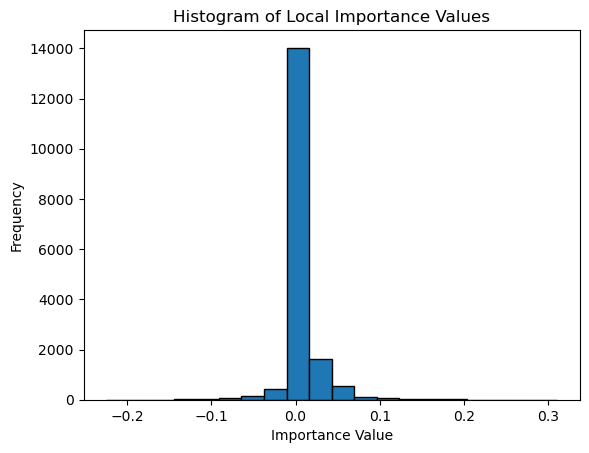

In [50]:
import matplotlib.pyplot as plt

plt.hist(res_mlp["local_imp"].values.flatten(), bins=20, edgecolor='k')
plt.title("Histogram of Local Importance Values")
plt.xlabel("Importance Value")
plt.ylabel("Frequency")
plt.show()

In [39]:
# --- 2-Fold Cross Validation ---
kf = KFold(n_splits=2, shuffle=True, random_state=42)
fold_accuracies = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"\n--- Fold {fold+1} ---")
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Build and train model
    model = build_mlp(input_dim=X.shape[1])
    model.fit(X_train, y_train,
              validation_data=(X_test, y_test),
              epochs=10,
              batch_size=32,
              verbose=0)
    
    # Evaluate
    y_pred = (model.predict(X_test) > 0.5).astype(int).ravel()
    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)
    print(f"Fold {fold+1} Accuracy: {acc:.4f}")

# --- Mean accuracy across folds ---
print("\nMean CV Accuracy:", np.mean(fold_accuracies).round(4))


--- Fold 1 ---
9/9 [==============================] - 0s 1ms/step
Fold 1 Accuracy: 0.9719

--- Fold 2 ---
9/9 [==============================] - 0s 2ms/step
Fold 2 Accuracy: 0.9542

Mean CV Accuracy: 0.9631
